In [1]:
import torch
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples = 1000, noise = 0.03, random_state = 42)

In [3]:
X[:5], y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [4]:
X.shape, y.shape

((1000, 2), (1000,))

In [5]:
dataset = pd.DataFrame({'X1': X[:, 0],
                        'X2': X[:, 1],
                        'label': y })

dataset.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


In [6]:
dataset.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

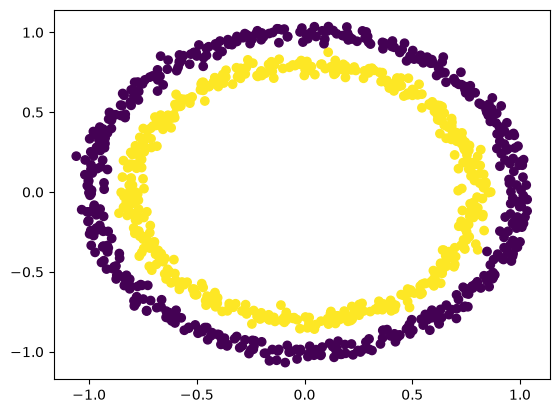

In [7]:
plt.scatter(x = X[:,0], y = X[:,1], c = y)

In [8]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [9]:
X.device, y.device

(device(type='cpu'), device(type='cpu'))

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [12]:
sampleModel = torch.nn.Sequential(
    torch.nn.Linear(in_features = 2, out_features = 5),
    torch.nn.Linear(in_features = 5, out_features = 1)
).to(device)

In [13]:
sampleModel

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [14]:
lose_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = (sampleModel.parameters()), lr = 0.01)

In [15]:
from sklearn.metrics import accuracy_score

In [16]:
torch.manual_seed(42)

epoch = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for ep in range(epoch):

    sampleModel.train()

    y_logits = sampleModel(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = lose_fn(y_logits, y_train)
    acc = accuracy_score(y_true = y_train.detach().cpu().numpy(), y_pred = y_pred.detach().cpu().numpy())

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    sampleModel.eval()

    with torch.inference_mode():

        test_logits = sampleModel(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = lose_fn(test_logits, y_test)
        test_acc = accuracy_score(y_true = y_test.detach().cpu().numpy(), y_pred = test_pred.detach().cpu().numpy())

        if ep % 50 == 0:
            print(f'epoch: {ep}\t||\ttrain BCE loss: {loss:.4f} || acc: {acc:.4f}\t||\ttest loss: {test_loss:.4f} || test acc: {test_acc:.4f}')

epoch: 0	||	train BCE loss: 0.7156 || acc: 0.4788	||	test loss: 0.7101 || test acc: 0.4700
epoch: 50	||	train BCE loss: 0.7092 || acc: 0.4838	||	test loss: 0.7043 || test acc: 0.5000
epoch: 100	||	train BCE loss: 0.7051 || acc: 0.4863	||	test loss: 0.7007 || test acc: 0.4900
epoch: 150	||	train BCE loss: 0.7023 || acc: 0.4875	||	test loss: 0.6983 || test acc: 0.5000
epoch: 200	||	train BCE loss: 0.7003 || acc: 0.4925	||	test loss: 0.6968 || test acc: 0.4950
epoch: 250	||	train BCE loss: 0.6989 || acc: 0.4963	||	test loss: 0.6957 || test acc: 0.4900
epoch: 300	||	train BCE loss: 0.6978 || acc: 0.5000	||	test loss: 0.6950 || test acc: 0.4850
epoch: 350	||	train BCE loss: 0.6970 || acc: 0.4975	||	test loss: 0.6944 || test acc: 0.4900
epoch: 400	||	train BCE loss: 0.6964 || acc: 0.4988	||	test loss: 0.6940 || test acc: 0.5000
epoch: 450	||	train BCE loss: 0.6959 || acc: 0.4988	||	test loss: 0.6937 || test acc: 0.5100
epoch: 500	||	train BCE loss: 0.6954 || acc: 0.4963	||	test loss: 0.6935 

In [17]:
from helper_functions import plot_predictions, plot_decision_boundary

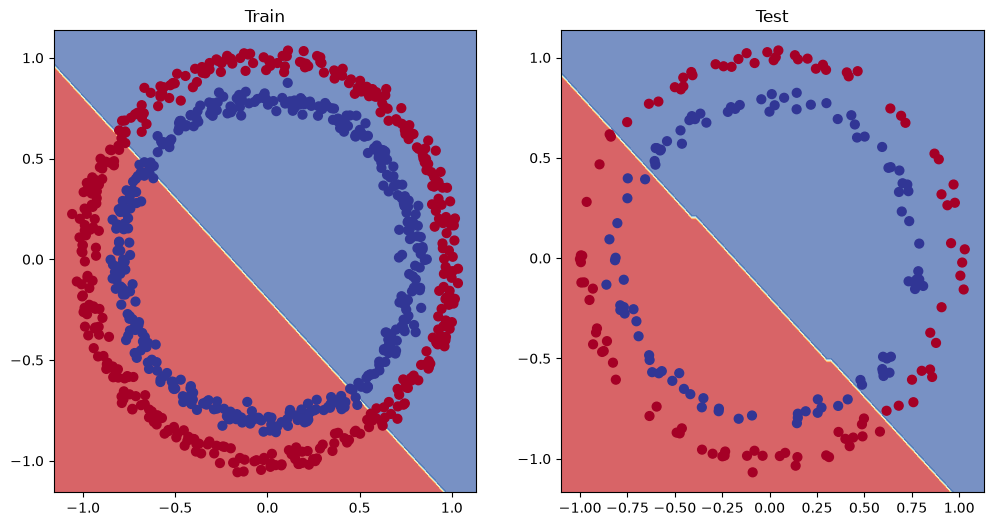

In [18]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(sampleModel, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(sampleModel, X_test, y_test)

In [19]:
class ClassificationModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = torch.nn.Linear(in_features=2, out_features=10)
        self.layer_2 = torch.nn.Linear(in_features=10, out_features=10) 
        self.layer_3 = torch.nn.Linear(in_features=10, out_features=1)
        
    def forward(self, x):
        return self.layer_3(self.layer_2(self.layer_1(x)))

In [20]:
model2 = ClassificationModel()
model2.to(device)

model2

ClassificationModel(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [21]:
lose_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = (model2.parameters()), lr = 0.01)

In [22]:
torch.manual_seed(42)

epoch = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for ep in range(epoch):

    model2.train()

    y_logits = model2(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = lose_fn(y_logits, y_train)
    acc = accuracy_score(y_true = y_train.detach().cpu().numpy(), y_pred = y_pred.detach().cpu().numpy())

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model2.eval()

    with torch.inference_mode():

        test_logits = model2(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = lose_fn(test_logits, y_test)
        test_acc = accuracy_score(y_true = y_test.detach().cpu().numpy(), y_pred = test_pred.detach().cpu().numpy())

        if ep % 50 == 0:
            print(f'epoch: {ep}\t||\ttrain BCE loss: {loss:.4f} || acc: {acc:.4f}\t||\ttest loss: {test_loss:.4f} || test acc: {test_acc:.4f}')

epoch: 0	||	train BCE loss: 0.6938 || acc: 0.5100	||	test loss: 0.6933 || test acc: 0.5050
epoch: 50	||	train BCE loss: 0.6937 || acc: 0.5012	||	test loss: 0.6933 || test acc: 0.5000
epoch: 100	||	train BCE loss: 0.6936 || acc: 0.5025	||	test loss: 0.6932 || test acc: 0.5000
epoch: 150	||	train BCE loss: 0.6935 || acc: 0.5025	||	test loss: 0.6932 || test acc: 0.5050
epoch: 200	||	train BCE loss: 0.6934 || acc: 0.4975	||	test loss: 0.6932 || test acc: 0.4950
epoch: 250	||	train BCE loss: 0.6934 || acc: 0.5000	||	test loss: 0.6933 || test acc: 0.5050
epoch: 300	||	train BCE loss: 0.6933 || acc: 0.4963	||	test loss: 0.6933 || test acc: 0.5100
epoch: 350	||	train BCE loss: 0.6933 || acc: 0.4938	||	test loss: 0.6933 || test acc: 0.5150
epoch: 400	||	train BCE loss: 0.6933 || acc: 0.4975	||	test loss: 0.6933 || test acc: 0.5150
epoch: 450	||	train BCE loss: 0.6932 || acc: 0.4975	||	test loss: 0.6933 || test acc: 0.5050
epoch: 500	||	train BCE loss: 0.6932 || acc: 0.4963	||	test loss: 0.6933 

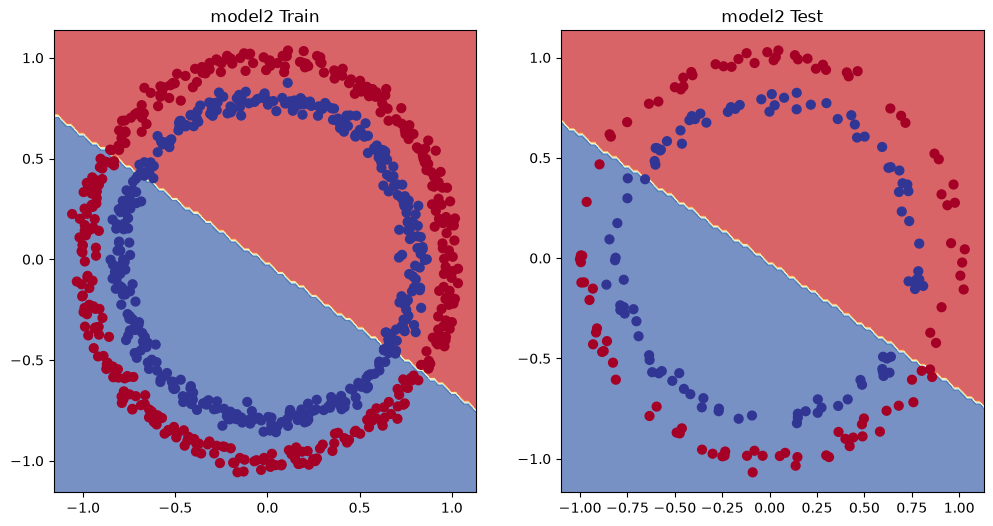

In [23]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("model2 Train")
plot_decision_boundary(model2, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("model2 Test")
plot_decision_boundary(model2, X_test, y_test)

In [24]:
from torch import nn
class NonLinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x):
       return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = NonLinearModel().to(device)
print(model_3)

NonLinearModel(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


In [25]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(), lr=0.1)

In [26]:
torch.manual_seed(42)

epoch = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for ep in range(epoch):

    model_3.train()

    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = lose_fn(y_logits, y_train)
    acc = accuracy_score(y_true = y_train.detach().cpu().numpy(), y_pred = y_pred.detach().cpu().numpy())

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_3.eval()

    with torch.inference_mode():

        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = lose_fn(test_logits, y_test)
        test_acc = accuracy_score(y_true = y_test.detach().cpu().numpy(), y_pred = test_pred.detach().cpu().numpy())

        if ep % 50 == 0:
            print(f'epoch: {ep}\t||\ttrain BCE loss: {loss:.4f} || acc: {acc:.4f}\t||\ttest loss: {test_loss:.4f} || test acc: {test_acc:.4f}')

epoch: 0	||	train BCE loss: 0.6929 || acc: 0.5000	||	test loss: 0.6933 || test acc: 0.5000
epoch: 50	||	train BCE loss: 0.6917 || acc: 0.5525	||	test loss: 0.6921 || test acc: 0.5450
epoch: 100	||	train BCE loss: 0.6908 || acc: 0.5337	||	test loss: 0.6916 || test acc: 0.5150
epoch: 150	||	train BCE loss: 0.6900 || acc: 0.5437	||	test loss: 0.6911 || test acc: 0.5050
epoch: 200	||	train BCE loss: 0.6890 || acc: 0.5437	||	test loss: 0.6906 || test acc: 0.5150
epoch: 250	||	train BCE loss: 0.6878 || acc: 0.5463	||	test loss: 0.6899 || test acc: 0.5100
epoch: 300	||	train BCE loss: 0.6864 || acc: 0.5487	||	test loss: 0.6889 || test acc: 0.5100
epoch: 350	||	train BCE loss: 0.6847 || acc: 0.5475	||	test loss: 0.6876 || test acc: 0.5000
epoch: 400	||	train BCE loss: 0.6827 || acc: 0.5463	||	test loss: 0.6860 || test acc: 0.5000
epoch: 450	||	train BCE loss: 0.6802 || acc: 0.5413	||	test loss: 0.6840 || test acc: 0.5000
epoch: 500	||	train BCE loss: 0.6773 || acc: 0.5387	||	test loss: 0.6817 

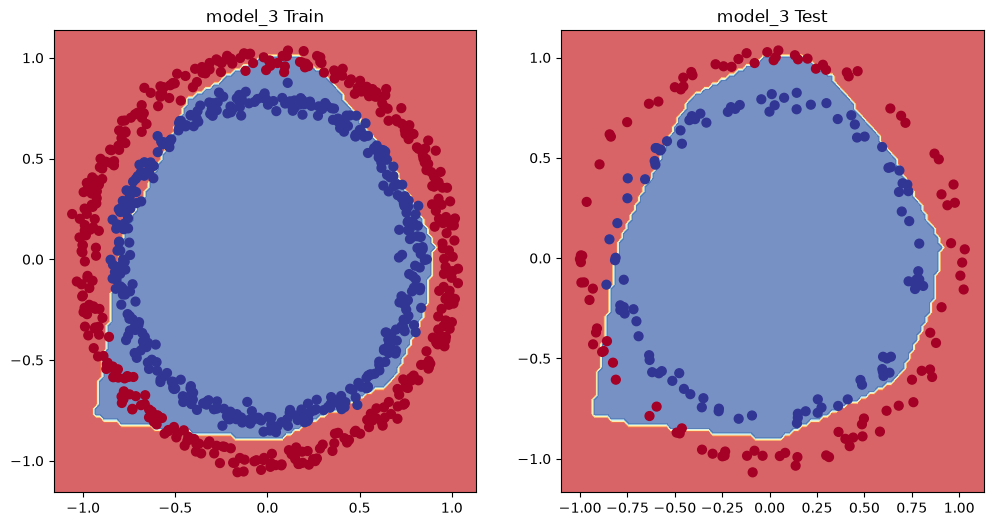

In [27]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("model_3 Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("model_3 Test")
plot_decision_boundary(model_3, X_test, y_test)